# 04 — SciVer EDA

Exploratory data analysis for the vectorized SciVer evidence-claim database.

This notebook starts with the three **Metadata EDA** tasks from `docs/CHECKPOINT_0605_AND_ROADMAP_FOR_EDA.md`:

1. **Dataset and schema checks** — sizes, columns, vector dimensions, missing values, cross-collection consistency.
2. **Label, split, and modality distributions** — the supervised population before any modeling.
3. **Evidence text and image availability** — caption/OCR/context lengths, empty-text rates, missing images, failed image embeddings.

It then continues with **Embedding EDA** (nearest neighbors, distance distributions, duplicate detection) in the section near the bottom.

---

### Prerequisite: build the data first

This notebook reads `data/processed/`, which is generated locally and is **not** stored in git. If the cells below report missing files, build the database first:

```bash
python scripts/build_sciver_qdrant.py --reset            # full build (with images)
python scripts/build_sciver_qdrant.py --reset --no-image-embeddings   # faster, text-only
```

Most of this notebook reads the **manifest parquet files**, which already contain every metadata column (including caption/OCR/context text). Cells that need the vectors open the Qdrant database directly. The `image_vec` checks gracefully skip themselves on a text-only build.

## 1. Setup

Resolve the repo root (works whether the notebook runs from the repo root or from inside `notebooks/`), import libraries, and define a small helper that loads a manifest with a clear error if the data has not been built yet.

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Resolve the repo root for both `jupyter notebook notebooks/...` and nbconvert from the repo root.
cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "sciver_vector_db").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
QDRANT_PATH = PROCESSED_DIR / "qdrant_sciver"

MANIFESTS = {
    "claims": PROCESSED_DIR / "sciver_claims_manifest.parquet",
    "evidence_items": PROCESSED_DIR / "sciver_evidence_items_manifest.parquet",
    "pairs": PROCESSED_DIR / "sciver_pairs_manifest.parquet",
}


def load_manifest(name):
    """Load one manifest parquet, or raise a clear 'build the data first' message."""
    path = MANIFESTS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Manifest '{name}' not found at {path}.\n"
            "Build the database first, for example:\n"
            "  python scripts/build_sciver_qdrant.py --reset\n"
            "  (add --no-image-embeddings for a faster text-only first build)."
        )
    return pd.read_parquet(path)


print("REPO_ROOT:", REPO_ROOT)
print("Processed dir exists:", PROCESSED_DIR.exists())
for _name, _path in MANIFESTS.items():
    print(f"  {_name:15s} {'OK' if _path.exists() else 'MISSING'}  {_path}")

REPO_ROOT: /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning
Processed dir exists: True
  claims          OK  /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning/data/processed/sciver_claims_manifest.parquet
  evidence_items  OK  /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning/data/processed/sciver_evidence_items_manifest.parquet
  pairs           OK  /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning/data/processed/sciver_pairs_manifest.parquet


In [2]:
# Load the three manifests once; reuse the DataFrames throughout the notebook.
claims = load_manifest("claims")
evidence = load_manifest("evidence_items")
pairs = load_manifest("pairs")

print("claims:        ", claims.shape)
print("evidence_items:", evidence.shape)
print("pairs:         ", pairs.shape)
pairs.head(3)

claims:         (1500, 11)
evidence_items: (1399, 14)
pairs:          (1500, 24)


,pair_id,claim_id,evidence_item_id,paperid,request_id,split,claim,label,label_id,claim_type,modality,image_path,section_json,n_evidence_items,gold_pair,pair_mode,caption,ocr_text,context_text,paper_path,item_key,feature_version,embedding_model_text,embedding_model_image
0,pair:val:2409.12320v1:4:83b5f9d5336cd9c6:aef29...,claim:val:2409.12320v1:4:83b5f9d5336cd9c6,evidence:2409.12320v1:chart:direct:824d2f2284f...,2409.12320v1,4,val,"Despite stable medians at 5, the 3.5% decline ...",entailed,1,analytical,chart,/Users/everett/Documents/TheErdosInstitute/Dat...,"[""5.2.1"", ""5.2.2""]",1,True,single_visual_only,,,,./SciVer/papers/2409.12320v1.json,direct,sciver_vector_db_v1,sentence-transformers/all-MiniLM-L6-v2,openai/clip-vit-base-patch32
1,pair:val:2410.08207v1:6:cc9e050f670f9f6a:921be...,claim:val:2410.08207v1:6:cc9e050f670f9f6a,evidence:2410.08207v1:chart:direct:02776ae7710...,2410.08207v1,6,val,The exponential λ schedule consistently yields...,entailed,1,analytical,chart,/Users/everett/Documents/TheErdosInstitute/Dat...,"[""3.2""]",1,True,single_visual_only,,,,./SciVer/papers/2410.08207v1.json,direct,sciver_vector_db_v1,sentence-transformers/all-MiniLM-L6-v2,openai/clip-vit-base-patch32
2,pair:val:2410.07073v2:8:ee39da00d96b3739:25533...,claim:val:2410.07073v2:8:ee39da00d96b3739,evidence:2410.07073v2:chart:direct:3a4fa044674...,2410.07073v2,8,val,The share of respondents 'not worried at all' ...,entailed,1,analytical,chart,/Users/everett/Documents/TheErdosInstitute/Dat...,"[""3"", ""5""]",1,True,single_visual_only,,,,./SciVer/papers/2410.07073v2.json,direct,sciver_vector_db_v1,sentence-transformers/all-MiniLM-L6-v2,openai/clip-vit-base-patch32


## Task 1 — Dataset and schema checks

Goal: confirm the build is valid and self-consistent before trusting any later analysis.

- row counts and columns for each collection
- missing-value report
- primary-key uniqueness
- cross-collection consistency (every `claim_id` / `evidence_item_id` referenced by `pairs` exists)
- vector names and dimensions in Qdrant (expected 384 / 384 / 384 for text, 512 for image)

In [3]:
# Row counts and columns for each manifest.
for name, df in [("claims", claims), ("evidence_items", evidence), ("pairs", pairs)]:
    print(f"=== {name} ===")
    print("  rows:", len(df))
    print("  cols:", list(df.columns))
    print()

=== claims ===
  rows: 1500
  cols: ['claim_id', 'paperid', 'request_id', 'split', 'claim', 'claim_type', 'label', 'label_id', 'evidence_item_ids_json', 'feature_version', 'embedding_model_text']

=== evidence_items ===
  rows: 1399
  cols: ['evidence_item_id', 'paperid', 'split', 'modality', 'item_key', 'image_path', 'caption', 'ocr_text', 'context_text', 'section_json', 'paper_path', 'feature_version', 'embedding_model_text', 'embedding_model_image']

=== pairs ===
  rows: 1500
  cols: ['pair_id', 'claim_id', 'evidence_item_id', 'paperid', 'request_id', 'split', 'claim', 'label', 'label_id', 'claim_type', 'modality', 'image_path', 'section_json', 'n_evidence_items', 'gold_pair', 'pair_mode', 'caption', 'ocr_text', 'context_text', 'paper_path', 'item_key', 'feature_version', 'embedding_model_text', 'embedding_model_image']



In [4]:
# Missing-value report: count NaNs per column (only columns that actually have nulls).
def null_report(df, name):
    rep = df.isna().sum()
    rep = rep[rep > 0]
    print(f"Nulls in {name}:")
    print("  none" if rep.empty else rep.to_string())
    print()

for name, df in [("claims", claims), ("evidence_items", evidence), ("pairs", pairs)]:
    null_report(df, name)

Nulls in claims:
  none

Nulls in evidence_items:
  none

Nulls in pairs:
  none



In [5]:
# Primary-key uniqueness and cross-collection referential consistency.
claim_ids = set(claims["claim_id"])
evidence_ids = set(evidence["evidence_item_id"])

orphan_claims = set(pairs["claim_id"]) - claim_ids
orphan_evidence = set(pairs["evidence_item_id"]) - evidence_ids

print("duplicate pair_id in pairs:           ", int(pairs["pair_id"].duplicated().sum()))
print("duplicate claim_id in claims:         ", int(claims["claim_id"].duplicated().sum()))
print("duplicate evidence_item_id in evidence:", int(evidence["evidence_item_id"].duplicated().sum()))
print()
print("pairs referencing a MISSING claim_id:        ", len(orphan_claims))
print("pairs referencing a MISSING evidence_item_id:", len(orphan_evidence))
if orphan_claims or orphan_evidence:
    print("\n[!] Orphan references found — the build may be inconsistent.")
else:
    print("\nOK: every pair points to an existing claim and evidence item.")

duplicate pair_id in pairs:            0
duplicate claim_id in claims:          0
duplicate evidence_item_id in evidence: 0

pairs referencing a MISSING claim_id:         0
pairs referencing a MISSING evidence_item_id: 0

OK: every pair points to an existing claim and evidence item.


In [6]:
# Vector names and dimensions, read directly from Qdrant.
# Local Qdrant allows only one open handle at a time, so we always close the client.
EXPECTED_DIMS = {"claim_vec": 384, "evidence_text_vec": 384, "pair_text_vec": 384, "image_vec": 512}

client = None
try:
    from qdrant_client import QdrantClient

    if not QDRANT_PATH.exists():
        raise FileNotFoundError(f"Qdrant database not found at {QDRANT_PATH}.")
    client = QdrantClient(path=str(QDRANT_PATH))
    for coll in ["sciver_claims", "sciver_evidence_items", "sciver_pairs"]:
        info = client.get_collection(coll)
        n = client.count(coll).count
        print(f"{coll}: {n} points")
        for vname, params in info.config.params.vectors.items():
            flag = ""
            if vname in EXPECTED_DIMS and params.size != EXPECTED_DIMS[vname]:
                flag = f"   <-- expected {EXPECTED_DIMS[vname]}"
            print(f"    {vname}: dim={params.size} distance={params.distance}{flag}")
        print()
except Exception as e:
    print("Skipping Qdrant dimension check:", type(e).__name__, e)
finally:
    if client is not None:
        client.close()

sciver_claims: 1500 points
    claim_vec: dim=384 distance=Cosine

sciver_evidence_items: 1399 points
    evidence_text_vec: dim=384 distance=Cosine
    image_vec: dim=512 distance=Cosine

sciver_pairs: 1500 points
    claim_vec: dim=384 distance=Cosine
    evidence_text_vec: dim=384 distance=Cosine
    pair_text_vec: dim=384 distance=Cosine
    image_vec: dim=512 distance=Cosine



## Task 2 — Label, split, and modality distribution analysis

Goal: understand the supervised population. Class imbalance makes raw accuracy misleading, so we look at `entailed` vs `refuted` overall and broken down by split, modality, claim type, paper, and evidence count.

In [7]:
# Single-column distributions on the supervised pair unit.
for col in ["label", "split", "modality", "claim_type"]:
    print(f"=== pairs by {col} ===")
    print(pairs[col].value_counts(dropna=False).to_string())
    print()

=== pairs by label ===
label
entailed    750
refuted     750

=== pairs by split ===
split
test    996
val     504

=== pairs by modality ===
modality
chart    817
table    683

=== pairs by claim_type ===
claim_type
analytical    750
direct        750



In [8]:
# Crosstabs: how the label splits across the key categorical fields.
print("label x split (counts):")
print(pd.crosstab(pairs["label"], pairs["split"]))
print("\nlabel share within each split (column-normalized):")
print(pd.crosstab(pairs["label"], pairs["split"], normalize="columns").round(3))
print("\nlabel x modality (counts):")
print(pd.crosstab(pairs["label"], pairs["modality"]))
print("\nlabel x claim_type (counts):")
print(pd.crosstab(pairs["label"], pairs["claim_type"]))

label x split (counts):
split     test  val
label              
entailed   502  248
refuted    494  256

label share within each split (column-normalized):
split      test    val
label                 
entailed  0.504  0.492
refuted   0.496  0.508

label x modality (counts):
modality  chart  table
label                 
entailed    409    341
refuted     408    342

label x claim_type (counts):
claim_type  analytical  direct
label                         
entailed           375     375
refuted            375     375


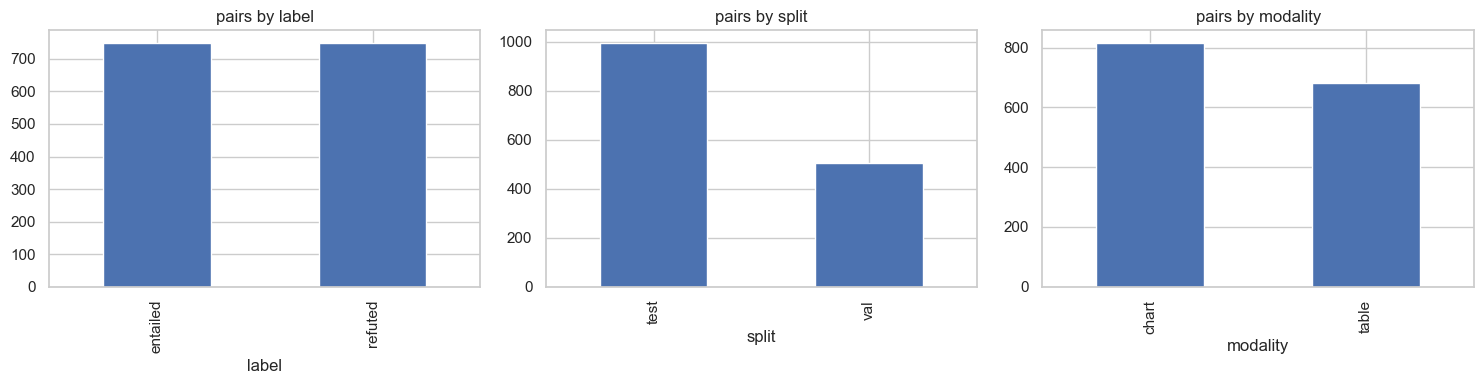

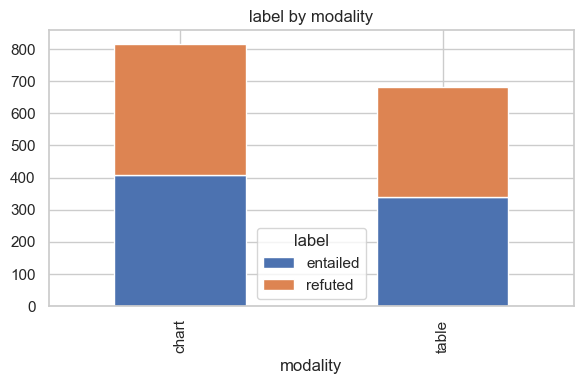

In [9]:
# Quick visual summary.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["label", "split", "modality"]):
    pairs[col].value_counts().plot.bar(ax=ax, title=f"pairs by {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

pd.crosstab(pairs["modality"], pairs["label"]).plot.bar(
    stacked=True, figsize=(6, 4), title="label by modality"
)
plt.tight_layout()
plt.show()

In [10]:
# Paper-level and evidence-count views.
print("unique papers:", pairs["paperid"].nunique())
print("\npairs per paper (summary):")
print(pairs.groupby("paperid").size().describe().round(2).to_string())
print("\nn_evidence_items distribution:")
print(pairs["n_evidence_items"].value_counts().sort_index().to_string())

unique papers: 962

pairs per paper (summary):
count    962.00
mean       1.56
std        0.50
min        1.00
25%        1.00
50%        2.00
75%        2.00
max        2.00

n_evidence_items distribution:
n_evidence_items
1    1500


## Task 3 — Evidence text and image availability analysis

Goal: measure how strong each example's evidence representation is. Weak evidence (empty captions, missing images, failed embeddings) can come from the dataset, the parser, or the embedding step — these checks help tell them apart.

- caption / OCR / context length distributions
- empty-text rates (overall and by split/modality)
- section-title availability
- missing image files on disk
- failed image embeddings (image present but no `image_vec` stored)

In [11]:
# Text length columns. The pairs manifest carries caption/ocr_text/context_text directly.
TEXT_FIELDS = ["caption", "ocr_text", "context_text"]
for f in TEXT_FIELDS:
    pairs[f + "_len"] = pairs[f].fillna("").str.len()

print("Character-length summary:")
print(pairs[[f + "_len" for f in TEXT_FIELDS]].describe().round(1))

Character-length summary:
       caption_len  ocr_text_len  context_text_len
count       1500.0        1500.0            1500.0
mean           0.0           0.0               0.0
std            0.0           0.0               0.0
min            0.0           0.0               0.0
25%            0.0           0.0               0.0
50%            0.0           0.0               0.0
75%            0.0           0.0               0.0
max            0.0           0.0               0.0


In [12]:
# Empty-text rates: how often a field is entirely blank.
for f in TEXT_FIELDS:
    pairs[f + "_empty"] = pairs[f].fillna("").str.strip() == ""

print("Overall empty-text rate:")
for f in TEXT_FIELDS:
    print(f"  {f:14s} {pairs[f + '_empty'].mean():.1%}")

print("\ncaption empty rate by modality:")
print(pairs.groupby("modality")["caption_empty"].mean().round(3).to_string())
print("\ncaption empty rate by split:")
print(pairs.groupby("split")["caption_empty"].mean().round(3).to_string())

Overall empty-text rate:
  caption        100.0%
  ocr_text       100.0%
  context_text   100.0%

caption empty rate by modality:
modality
chart    1.0
table    1.0

caption empty rate by split:
split
test    1.0
val     1.0


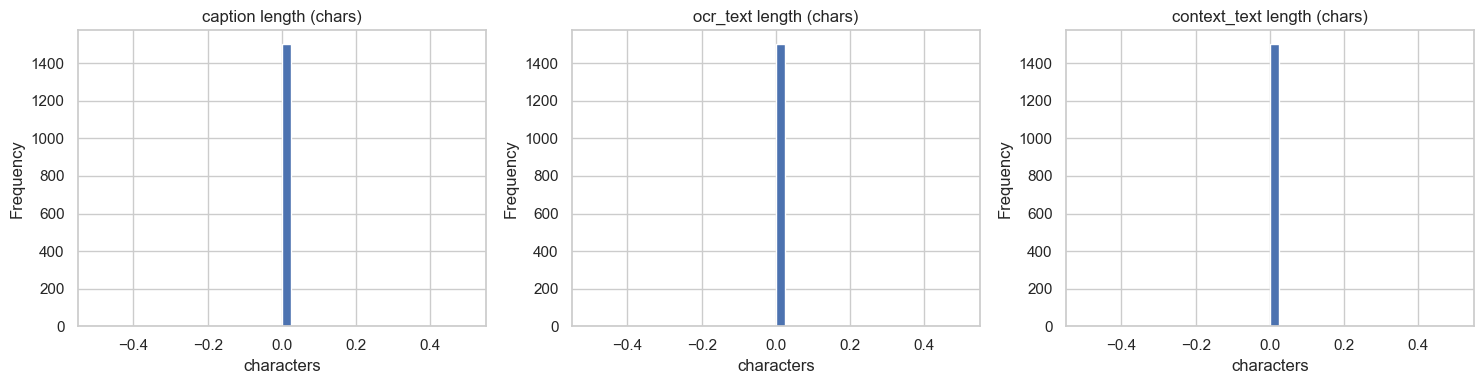

In [13]:
# Length histograms (clipped at the 99th percentile so a few long outliers don't flatten the plot).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, TEXT_FIELDS):
    col = pairs[f + "_len"]
    upper = max(col.quantile(0.99), 1)
    col.clip(upper=upper).plot.hist(bins=40, ax=ax, title=f"{f} length (chars)")
    ax.set_xlabel("characters")
plt.tight_layout()
plt.show()

In [14]:
# Section-title availability: section_json is stored as a JSON string when present.
def has_section(value):
    if not isinstance(value, str) or not value.strip():
        return False
    try:
        return bool(json.loads(value))
    except Exception:
        return bool(value.strip())

pairs["has_section"] = pairs["section_json"].apply(has_section)
print("section availability (share of pairs):")
print(pairs["has_section"].value_counts(normalize=True).round(3).to_string())

section availability (share of pairs):
has_section
True    1.0


In [15]:
# Missing image files: check the stored image_path against the local filesystem.
# Deduplicate by evidence_item_id so each chart/table image is counted once.
def resolve_image(p):
    if not isinstance(p, str) or not p:
        return None
    path = Path(p)
    if not path.is_absolute():
        path = REPO_ROOT / path
    return path

img = pairs.drop_duplicates("evidence_item_id").copy()
img["img_resolved"] = img["image_path"].apply(resolve_image)
img["img_exists"] = img["img_resolved"].apply(lambda p: bool(p) and p.exists())

has_path = img["image_path"].fillna("").ne("").sum()
print(f"unique evidence items:          {len(img)}")
print(f"evidence items with image_path: {int(has_path)}")
print(f"image files found on disk:      {int(img['img_exists'].sum())}")
print(f"missing image files:            {int((~img['img_exists']).sum())}")

unique evidence items:          1399
evidence items with image_path: 1399
image files found on disk:      1399
missing image files:            0


In [16]:
# Failed image embeddings: an image_vec is expected for each evidence item, but the
# build may skip some (load/decoding failures). Compare stored vectors against the total.
# This cell is a no-op if the database was built with --no-image-embeddings.
client = None
try:
    from qdrant_client import QdrantClient
    from sciver_vector_db.qdrant_store import scroll_all

    if not QDRANT_PATH.exists():
        raise FileNotFoundError(f"Qdrant database not found at {QDRANT_PATH}.")
    client = QdrantClient(path=str(QDRANT_PATH))
    info = client.get_collection("sciver_evidence_items")
    if "image_vec" not in info.config.params.vectors:
        print("No image_vec in this build (likely --no-image-embeddings). Skipping.")
    else:
        total = 0
        with_vec = 0
        for pt in scroll_all(client, "sciver_evidence_items", with_vectors=True):
            total += 1
            vectors = pt.vector or {}
            if isinstance(vectors, dict) and vectors.get("image_vec") is not None:
                with_vec += 1
        print(f"evidence items with image_vec: {with_vec}/{total}")
        print(f"missing image_vec:             {total - with_vec}")
except Exception as e:
    print("Skipping image-embedding check:", type(e).__name__, e)
finally:
    if client is not None:
        client.close()

evidence items with image_vec: 1399/1399
missing image_vec:             0


## Metadata EDA — takeaways

Fill this in after running the cells above, using the numbers they print. Prompts:

- **Schema/consistency:** Row counts appear to be sensible, vector dimensions are as expected (384/384/384, plus 512 if images were built), and there are no orphan references.
- **Labels:** The number of `entailed` vs. `refuted` claims appears balanced across split, modality, and claim type.
- **Evidence quality:** No image files are missing or unembedded, but all of the textual evidence fields are empty. We need to address the missing textual evidence and rerun some of the above checks.

These conclusions set the ground rules for the baseline modeling work in `notebooks/02_direct_chart_logistic_regression.ipynb`.

---

# Embedding EDA

The cells below operate on the **vectors themselves** rather than the metadata columns. SciVer vectors are stored cosine-normalized, so a dot product between two vectors equals their cosine similarity.

Three tasks from the roadmap:

1. **Nearest-neighbor inspection by vector type** — do a seed's neighbors share its label, modality, claim type, and paper?
2. **Similarity / distance distributions** — same-label vs different-label, same-paper vs different-paper, same-modality vs cross-modality.
3. **Duplicate, near-duplicate, and split-neighborhood checks** — repeated claims / captions / images, and near-duplicate evidence across the val/test split (a leakage risk).

> On a **text-only build**, `image_vec` is absent. Every cell below detects which vectors exist and simply skips `image_vec` when it is not present.

## Embedding setup — load vectors into memory

Scroll every `sciver_pairs` point once, building an aligned metadata table (`emb_meta`) and a dict of normalized vector matrices (`emb_vecs`). Tasks 2 and 3 reuse these in-memory arrays; Task 1 re-opens Qdrant for live nearest-neighbor search.

In [17]:
from qdrant_client import QdrantClient
from sciver_vector_db.qdrant_store import scroll_all

EMB_COLLECTION = "sciver_pairs"

emb_meta = pd.DataFrame()
emb_vecs = {}
emb_present = []

client = None
try:
    if not QDRANT_PATH.exists():
        raise FileNotFoundError(f"Qdrant database not found at {QDRANT_PATH}.")
    client = QdrantClient(path=str(QDRANT_PATH))
    emb_present = list(client.get_collection(EMB_COLLECTION).config.params.vectors.keys())
    print("vectors present in", EMB_COLLECTION, ":", emb_present)

    rows = []
    collected = {name: [] for name in emb_present}
    for pt in scroll_all(client, EMB_COLLECTION, with_vectors=True):
        payload = pt.payload or {}
        vectors = pt.vector or {}
        # Keep only points that have every present vector, so the matrices stay row-aligned.
        if not all(vectors.get(name) is not None for name in emb_present):
            continue
        rows.append(payload)
        for name in emb_present:
            collected[name].append(vectors[name])

    emb_meta = pd.DataFrame(rows).reset_index(drop=True)
    for name in emb_present:
        M = np.asarray(collected[name], dtype=np.float32)
        norms = np.linalg.norm(M, axis=1, keepdims=True)
        norms[norms == 0] = 1.0  # defensive: avoid divide-by-zero
        emb_vecs[name] = M / norms
finally:
    if client is not None:
        client.close()

print("loaded pairs:", len(emb_meta))
for name, M in emb_vecs.items():
    print(f"  {name}: {M.shape}")

vectors present in sciver_pairs : ['claim_vec', 'evidence_text_vec', 'pair_text_vec', 'image_vec']
loaded pairs: 1500
  claim_vec: (1500, 384)
  evidence_text_vec: (1500, 384)
  pair_text_vec: (1500, 384)
  image_vec: (1500, 512)


## Embedding Task 1 — Nearest-neighbor inspection by vector type

For a few seed pairs, query each available vector and report how often the top neighbors share the seed's `label`, `modality`, `claim_type`, and `paperid`. High agreement means that vector geometry encodes that property; high `paperid` agreement in particular is an early warning of paper-level leakage.

In [27]:
from sciver_vector_db.qdrant_store import query_points

N_SEEDS = 10
N_NEIGHBORS = 10
META_KEYS = ["label", "modality", "claim_type", "paperid"]

client = None
try:
    client = QdrantClient(path=str(QDRANT_PATH))
    present = list(client.get_collection(EMB_COLLECTION).config.params.vectors.keys())
    seeds, _ = client.scroll(EMB_COLLECTION, limit=N_SEEDS, with_payload=True, with_vectors=True)

    for seed in seeds:
        sp = seed.payload or {}
        sv = seed.vector or {}
        print("=" * 80)
        print("SEED pair_id:", sp.get("pair_id"), "|", {k: sp.get(k) for k in META_KEYS})
        print("   claim:", (sp.get("claim") or "")[:100])
        for name in present:
            if sv.get(name) is None:
                continue
            hits = query_points(client, EMB_COLLECTION, vector_name=name, vector=sv[name], limit=N_NEIGHBORS + 1)
            hits = [h for h in hits if (h.payload or {}).get("pair_id") != sp.get("pair_id")][:N_NEIGHBORS]
            agree = {
                k: round(float(np.mean([1.0 if (h.payload or {}).get(k) == sp.get(k) else 0.0 for h in hits])), 2)
                for k in META_KEYS
            }
            print(f"   [{name:16s}] neighbor agreement {agree}")
finally:
    if client is not None:
        client.close()

SEED pair_id: pair:test:2410.02099v1:371:d57edfe168a79dd1:63021494fd98506d | {'label': 'entailed', 'modality': 'table', 'claim_type': 'analytical', 'paperid': '2410.02099v1'}
   claim: In the Flat watermark (k=1) scheme, pAUC increases from 68.8% to 90.0% as sample count n grows from 
   [claim_vec       ] neighbor agreement {'label': 0.4, 'modality': 0.4, 'claim_type': 0.4, 'paperid': 0.0}
   [evidence_text_vec] neighbor agreement {'label': 0.3, 'modality': 0.7, 'claim_type': 0.1, 'paperid': 0.0}
   [pair_text_vec   ] neighbor agreement {'label': 0.4, 'modality': 0.4, 'claim_type': 0.4, 'paperid': 0.0}
   [image_vec       ] neighbor agreement {'label': 0.5, 'modality': 1.0, 'claim_type': 0.5, 'paperid': 0.0}
SEED pair_id: pair:val:2409.16914v1:780:a358f64d1130c79b:2fcf523b287de5ee | {'label': 'refuted', 'modality': 'chart', 'claim_type': 'analytical', 'paperid': '2409.16914v1'}
   claim: At 45 tokens, two distinct cohesiveness peaks appear around 0.05 for human text and 0.5 for LLM ou

## Embedding Task 2 — Similarity and distance distribution analysis

Sample many random pairs of points and compare their cosine similarity, grouped by whether they share `label`, `paperid`, or `modality`. If same-label pairs are systematically more similar than different-label pairs, the embedding space has geometric signal a linear classifier can exploit. A large same-paper vs different-paper gap warns of paper-level structure (possible leakage).

Using vector: pair_text_vec
  label   : mean(same)=0.162  mean(diff)=0.163
  paperid : mean(same)=0.297  mean(diff)=0.162
  modality: mean(same)=0.163  mean(diff)=0.162


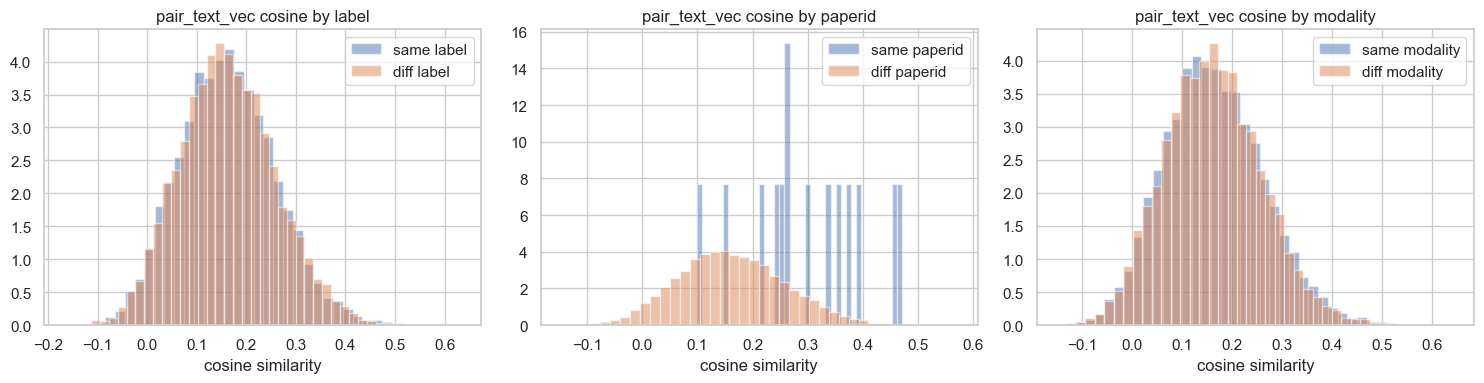

In [23]:
rng = np.random.default_rng(0)

def sample_pair_similarities(M, meta, key, n_pairs=20000):
    """Cosine similarity for random index pairs, plus a same/different mask for `key`."""
    n = len(M)
    i = rng.integers(0, n, size=n_pairs)
    j = rng.integers(0, n, size=n_pairs)
    keep = i != j
    i, j = i[keep], j[keep]
    sims = np.sum(M[i] * M[j], axis=1)  # dot == cosine for normalized vectors
    values = meta[key].to_numpy()
    same = values[i] == values[j]
    return sims, same

# Default to pair_text_vec; change this to inspect claim_vec / evidence_text_vec / image_vec.
VEC_FOR_DIST = "pair_text_vec" if "pair_text_vec" in emb_vecs else (emb_present[0] if emb_present else None)
if VEC_FOR_DIST is None:
    print("No vectors loaded. Run the embedding setup cell first.")
else:
    print("Using vector:", VEC_FOR_DIST)
    M = emb_vecs[VEC_FOR_DIST]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key in zip(axes, ["label", "paperid", "modality"]):
        if key not in emb_meta.columns:
            ax.set_title(f"{key} (missing)")
            continue
        sims, same = sample_pair_similarities(M, emb_meta, key)
        ax.hist(sims[same], bins=40, alpha=0.5, density=True, label=f"same {key}")
        ax.hist(sims[~same], bins=40, alpha=0.5, density=True, label=f"diff {key}")
        ax.set_title(f"{VEC_FOR_DIST} cosine by {key}")
        ax.set_xlabel("cosine similarity")
        ax.legend()
        print(f"  {key:8s}: mean(same)={sims[same].mean():.3f}  mean(diff)={sims[~same].mean():.3f}")
    plt.tight_layout()
    plt.show()

## Embedding Task 3 — Duplicate, near-duplicate, and split-neighborhood checks

First, exact repeats found via metadata (identical claim text, caption, or image path). Then near-duplicates found via embedding similarity. The most important signal is anything that repeats **across the val/test split**, because train-neighbor or retrieval features built on duplicated content would leak.

In [24]:
# Exact repeats via metadata.
for col in ["claim", "caption", "image_path"]:
    if col not in emb_meta.columns:
        print(f"{col}: not in metadata; skipping")
        continue
    s = emb_meta[col].fillna("").str.strip()
    s = s[s != ""]
    dup_mask = s.duplicated(keep=False)
    print(f"{col:11s}: {s[dup_mask].nunique()} distinct values repeated across {int(dup_mask.sum())} rows")

# Cross-split exact repeats (a direct leakage signal): same claim text in more than one split.
if {"claim", "split"}.issubset(emb_meta.columns):
    g = emb_meta.assign(_claim=emb_meta["claim"].fillna("").str.strip())
    g = g[g["_claim"] != ""]
    splits_per_claim = g.groupby("_claim")["split"].nunique()
    print(f"\nclaims appearing in more than one split: {int((splits_per_claim > 1).sum())}")

claim      : 0 distinct values repeated across 0 rows
caption: not in metadata; skipping
image_path : 101 distinct values repeated across 202 rows

claims appearing in more than one split: 0


In [30]:
# Near-duplicates via embedding similarity. With normalized vectors, S = M @ M.T is the cosine matrix.
# This dense all-pairs approach is fine for a few thousand pairs; for much larger collections,
# switch to per-point Qdrant search with a score threshold instead.
DUP_THRESHOLD = 0.98
VEC_FOR_DUP = "pair_text_vec" if "pair_text_vec" in emb_vecs else (emb_present[0] if emb_present else None)

if VEC_FOR_DUP is None:
    print("No vectors loaded. Run the embedding setup cell first.")
elif len(emb_vecs[VEC_FOR_DUP]) > 8000:
    print("Collection too large for dense all-pairs; use Qdrant per-point search instead.")
else:
    M = emb_vecs[VEC_FOR_DUP]
    print("Using vector:", VEC_FOR_DUP, "| n =", len(M))
    S = M @ M.T
    iu = np.triu_indices(len(M), k=1)  # upper triangle, exclude self-pairs
    sims = S[iu]
    hi = sims >= DUP_THRESHOLD
    a, b = iu[0][hi], iu[1][hi]
    split = emb_meta["split"].to_numpy()
    cross = split[a] != split[b]
    print(f"near-duplicate pairs (cosine >= {DUP_THRESHOLD}): {int(hi.sum())}")
    print(f"  of which cross-split (e.g. val<->test): {int(cross.sum())}")
    for k in np.where(cross)[0][:5]:
        ia, ib = int(a[k]), int(b[k])
        print(f"\n  cos={S[ia, ib]:.3f}")
        print(f"    [{split[ia]}] {(emb_meta.iloc[ia].get('claim') or '')[:70]!r}")
        print(f"    [{split[ib]}] {(emb_meta.iloc[ib].get('claim') or '')[:70]!r}")

Using vector: pair_text_vec | n = 1500
near-duplicate pairs (cosine >= 0.98): 0
  of which cross-split (e.g. val<->test): 0


## Embedding EDA — takeaways

Fill in after running the cells above:

- **Neighbor structure:** Although the `paperid` agreement among neighbors is not worryingly high, the vector type that best groups same-label neighbors is `evidence_text_vec`, which is not what we want since, as mentioned previously, the evidence text is always empty. The `pair_text_vec` vector type also seems to do a decent job of grouping same-neighbor pairs.
- **Separation:** Unfortunately, there is not a clear same-label vs. different-label similarity gap for any of the vector types, which means the embeddings may not have a clear geometric structure that can be exploited by a simple classifier.
- **Leakage:** No claim or images appear to be repeated across the validation/test split, and there are very few or no near-duplicate cross-split pairs using the `claim`, `pair_text_vec`, and `image_vec` vector types.